# Lagrangian-weighted voltage fitting

Global bound in the scattered-voltage basis $x = V_\mathrm{sca} = -Z_0 I$ (as in `VscatBound.ipynb`) → GCD refinement → inferred density
from the Lagrangian-weighted fit (as in `lagrangianCurrentFitting.ipynb`)

$$\min_{\rho\in[0,1]^N} \left(x^\star - B\rho\right)^H L^\star \left(x^\star - B\rho\right),\qquad B = -Z_0\,\mathrm{diag}\!\left(\frac{V + V^\star_\mathrm{sca}}{Z_s}\right),$$

where $L^\star = A(\lambda^\star)$ is the quadratic part of the Lagrangian at the optimal multipliers, and $B\rho$ is the scattered voltage of the
current $I_i = \rho_i (V + V^\star_\mathrm{sca})_i / Z_s$ induced by the total field of the optimal solution in a material of density $\rho$.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters
import copy
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dolphindes.cvxopt.gcd import GCDHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective and power conservation in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$, the radiated power is $-x^H A_0 x$ with $A_0 = -\tfrac12 W^H R_0 W$, and the power conservation
constraints take the shared projector form with $A_1 = 1 + Z_s^* W^H$, $A_2 = W$, $s_1 = -\tfrac12 V$ (derivation in `VscatBound.ipynb`).

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)


In [5]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-3.73e-13 (direct -3.72e-13)', '2.64e-12 (direct 2.64e-12)']
random p, random x: shared form 2.861286e-01, direct 2.861286e-01


## Global bound

In [6]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, 0.0])   # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.06s, Lagrange multipliers: [ 0.98806808 -0.03777126]
minimum eigenvalue of A: 1.813e-06
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W (I basis 1.012093e+01 W), full plate 1.010821e+01 W
constraint residuals at x*: ['4.99e-09', '6.68e-08']


## Local projector constraints by GCD

In [7]:
Ngcd = 40   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             10.120932760127525.
min eigenvalue: 1.812902e-06


At GCD iteration #2, best dual bound found is             10.113198452252561.
min eigenvalue: 1.421460e-06
At GCD iteration #3, best dual bound found is             10.113175883304194.
min eigenvalue: 1.420208e-06


At GCD iteration #4, best dual bound found is             10.112937262544774.
min eigenvalue: 1.408314e-06
At GCD iteration #5, best dual bound found is             10.11187875389079.
min eigenvalue: 1.353023e-06


At GCD iteration #6, best dual bound found is             10.111399171987191.
min eigenvalue: 1.326254e-06
At GCD iteration #7, best dual bound found is             10.111025492274232.
min eigenvalue: 1.304832e-06


At GCD iteration #8, best dual bound found is             10.110879420626304.
min eigenvalue: 1.296015e-06
At GCD iteration #9, best dual bound found is             10.110797317892054.
min eigenvalue: 1.290926e-06


...

At GCD iteration #37, best dual bound found is             10.108666035501695.
min eigenvalue: 1.130855e-06


At GCD iteration #38, best dual bound found is             10.108638794026565.
min eigenvalue: 1.128697e-06


At GCD iteration #39, best dual bound found is             10.10861397176907.
min eigenvalue: 1.126764e-06


At GCD iteration #40, best dual bound found is             10.10858704150004.
min eigenvalue: 1.124728e-06


At GCD iteration #41, best dual bound found is             10.10856182562412.
bound: 1.012093e+01 -> 1.010856e+01 W (full plate 1.010821e+01 W), 82 projectors, 12.87s


In [8]:
# finetune the GCD multipliers with BFGS and check PSD-ness of A
t1 = time.time()
gcd_final_result = gQCQP.solve_current_dual_problem(method='bfgs', init_lags=gQCQP.current_lags, opt_params=None)
print(f"bound: {gcd_final_result[0]:.6e} W, time: {time.time()-t1:.2f}s")

print(f"min eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
Vstar = gQCQP.current_xstar
print(f"GCD primal objective: {evalObj(Vstar):.6e} W, GCD dual bound: {gQCQP.current_dual:.6e} W")

bound: 1.010856e+01 W, time: 0.35s
min eigenvalue of A: 1.123e-06
GCD primal objective: 1.010856e+01 W, GCD dual bound: 1.010856e+01 W


## Lagrangian-weighted density fit

The deviation of the Lagrangian from its optimum is $(x - x^\star)^H L^\star (x - x^\star)$, so $L^\star$ weights the misfit of the scattered
voltage. With $b = (V + V^\star_\mathrm{sca})/Z_s$ the material of density $\rho$ carries $I = \mathrm{diag}(b)\rho$, i.e. $x = B\rho$,
$B = -Z_0\,\mathrm{diag}(b)$. The fit is the box-constrained QP
$$\min_{\rho\in[0,1]^N} \rho^T H \rho + 2 f^T\rho,\qquad H = \operatorname{Re}(B^H L^\star B),\quad f = -\operatorname{Re}(B^H L^\star x^\star).$$
It is compared with the ratio $\rho_i = \operatorname{Re}(Z_s I_i / (V + V_\mathrm{sca})_i)$ and the pointwise current fit of `VscatBound.ipynb`.

In [9]:
Vopt = gQCQP.current_xstar
Iopt = VtoI(Vopt)
Lstar = Msym(gQCQP._get_total_A(gQCQP.current_lags))   # quadratic part of the Lagrangian (Vsca basis)
print(f"min eig L*: {np.min(np.linalg.eigvalsh(Lstar)):.3e}")

Etot = Vinc + Vopt               # total field of the optimal solution
b = Etot / Zs                    # current of full material for this total field
Bfit = -Z0 * b[None, :]          # x = Bfit rho = -Z0 diag(b) rho

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I), I

# density fitting (ratio + clip)
dens_ratio = np.clip(np.real(Zs*Iopt/Etot), 0, 1)
# pointwise current fitting
dens_point = np.clip(np.real(b.conj()*Iopt)/np.abs(b)**2, 0, 1)

min eig L*: 1.123e-06


In [10]:
# Lagrangian-weighted fit: box-constrained QP with H = Re[B^H L B], f = -Re[B^H L x*]
LB = Lstar @ Bfit
H = np.real(Bfit.conj().T @ LB); H = 0.5*(H + H.T)
f = -np.real(LB.conj().T @ Vopt)
scale = np.max(np.abs(np.diag(H)))

fun = lambda s: ((s @ H @ s) + 2*(f @ s)) / scale
jac = lambda s: 2*(H @ s + f) / scale

t1 = time.time()
res = minimize(fun, dens_point, jac=jac, method='L-BFGS-B', bounds=[(0, 1)]*Ndes,
               options={'maxiter': 20000, 'ftol': 1e-15, 'gtol': 1e-12})
dens_lag = res.x
print(f"L-BFGS-B: {res.message}, iters {res.nit}, time {time.time()-t1:.2f}s")

def lagResidual(rho):
    r = Vopt - Bfit @ rho
    return np.real(r.conj() @ Lstar @ r)

print(f"dual bound: {gQCQP.current_dual:.6e} W, full plate: {Pfull:.6e} W")
results = {}
for name, d in [('ratio clip', dens_ratio), ('pointwise current', dens_point), ('Lagrangian-weighted', dens_lag)]:
    P, _ = realizedObj(d)
    results[name] = d
    print(f"{name:22s} objective {P:.6e} W | L*-residual {lagResidual(d):.3e} | mean density {d.mean():.3f}")

L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH, iters 999, time 0.02s
dual bound: 1.010856e+01 W, full plate: 1.010821e+01 W
ratio clip             objective 2.113968e-07 W | L*-residual 1.070e+03 | mean density 0.017
pointwise current      objective 2.113968e-07 W | L*-residual 1.070e+03 | mean density 0.017
Lagrangian-weighted    objective 1.773996e-07 W | L*-residual 1.010e+01 | mean density 0.000


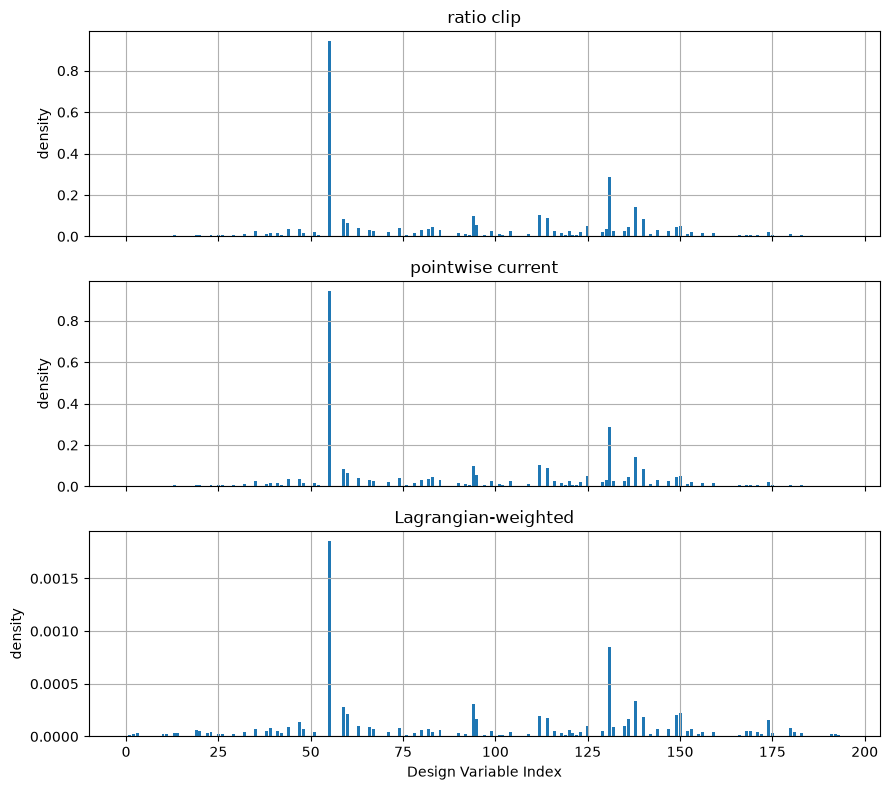

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for a_, (name, d) in zip(ax, results.items()):
    a_.bar(np.arange(Ndes), d)
    a_.set_ylabel('density'); a_.set_title(name); a_.grid(True)
ax[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

best threshold 0.05: objective 0.000000e+00 W


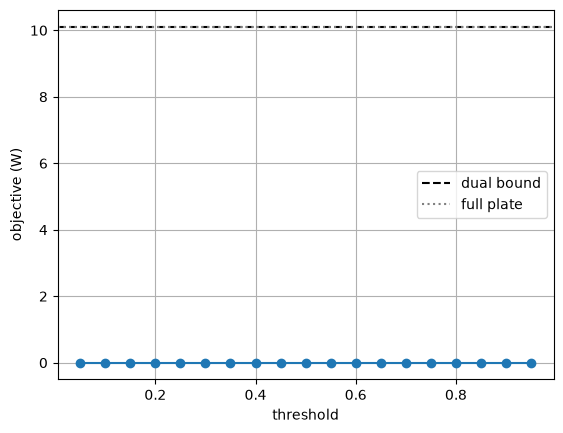

In [12]:
# binary rounding of the Lagrangian-weighted design: threshold sweep
ths = np.linspace(0.05, 0.95, 19)
Pbin = [realizedObj((dens_lag > t).astype(float))[0] for t in ths]
tbest = ths[int(np.argmax(Pbin))]
print(f"best threshold {tbest:.2f}: objective {max(Pbin):.6e} W")
plt.plot(ths, Pbin, 'o-'); plt.axhline(gQCQP.current_dual, ls='--', c='k', label='dual bound')
plt.axhline(Pfull, ls=':', c='gray', label='full plate')
plt.xlabel('threshold'); plt.ylabel('objective (W)'); plt.legend(); plt.grid(True); plt.show()
np.savetxt('lagrangian_voltage_fit_density.txt', dens_lag, delimiter=',')